In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import matplotlib as mpl

In [2]:
img_path = "./ovarian/processed/grid/tile_8593_level0_26976-23904-27200-24128.png"

In [3]:
img = io.imread(img_path)

In [4]:
x_dim, y_dim, z_dim = np.shape(img)

In [5]:
heatmap = np.zeros((x_dim, y_dim), dtype=float)

In [6]:
heatmap.shape

(224, 224)

In [7]:
x_ul=100
y_ul=100
x_br=150
y_br=150
heatmap[y_ul:y_br, x_ul:x_br] = 1.0

In [8]:
x_ul=50
y_ul=50
x_br=100
y_br=100
heatmap[y_ul:y_br, x_ul:x_br] = 0.5

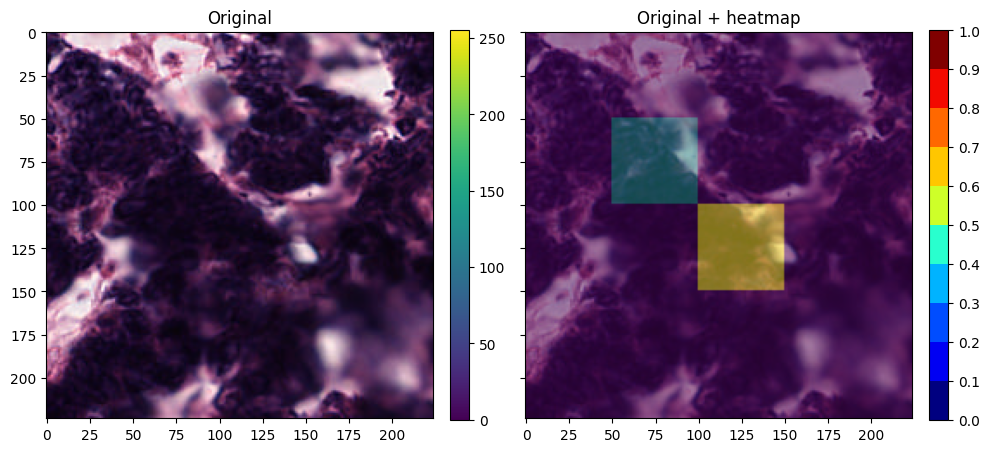

In [19]:
fig, axes = plt.subplots(1,2, figsize=(10, 5), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(img)
ax[0].set_title("Original")
fig.colorbar(ax[0].imshow(img), ax=ax[0], fraction=0.046, pad=0.04)

ax[1].imshow(img, vmin=0, vmax=1)
ax[1].imshow(heatmap, alpha=0.5, cmap='viridis', interpolation='bilinear')
ax[1].set_title("Original + heatmap")

# Specific colorbar
norm = mpl.colors.Normalize(vmin=0,vmax=1)
N = 11
cmap = plt.get_cmap('jet',N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax[1], ticks=np.linspace(0,1,N), boundaries=np.arange(0,1.1,0.1), fraction=0.046, pad=0.04) 

fig.tight_layout()
plt.show()